# 01 - Exploratory data analysis (MovieLens-1M)

What I wanted to know before training anything:

1. how skewed user activity and item popularity are (long tail),
2. what the time dimension looks like, because the split depends on it,
3. what metadata there is for content / cold-start models,
4. what the evaluation users look like after the split.

The plotting functions live in `src/recsysx/analysis/eda.py`, `scripts/run_eda.py` produces the same figures for `results/figures/`.

In [1]:
import numpy as np
import pandas as pd
from IPython.display import Image, display

from recsysx.config import load_config
from recsysx.data import RecData
from recsysx.analysis import eda

cfg = load_config()
data = RecData.load(cfg)
inter, users, items = data.interactions, data.users, data.items
print(inter.shape, users.shape, items.shape)
inter.head()

(1000209, 6) (6040, 12) (3706, 9)


,user_idx,item_idx,rating,timestamp,positive,period
0,6039,802,4,956703932,True,train
1,6039,579,5,956703954,True,train
2,6039,2191,4,956703954,True,train
3,6039,1781,4,956703977,True,train
4,6039,1839,5,956703977,True,train


In [2]:
items[["item_idx", "movie_id", "title", "year", "genres"]].head()

,item_idx,movie_id,title,year,genres
0,0,1,Toy Story (1995),1995.0,Animation|Children's|Comedy
1,1,2,Jumanji (1995),1995.0,Adventure|Children's|Fantasy
2,2,3,Grumpier Old Men (1995),1995.0,Comedy|Romance
3,3,4,Waiting to Exhale (1995),1995.0,Comedy|Drama
4,4,5,Father of the Bride Part II (1995),1995.0,Comedy


In [3]:
users[["user_idx", "user_id", "gender", "age", "occupation", "zip"]].head()

,user_idx,user_id,gender,age,occupation,zip
0,0,1,F,1,10,48067
1,1,2,M,56,16,70072
2,2,3,M,25,15,55117
3,3,4,M,45,7,02460
4,4,5,M,25,20,55455


## Basic statistics

In [4]:
summary = eda.dataset_summary(data)
pd.Series({k: v for k, v in summary.items() if not isinstance(v, dict)}).to_frame("value")

,value
users,6040
items,3706
ratings,1000209
positive_ratings (>=4),575281
positive_share,0.575161
density,0.044684
sparsity,0.955316
ratings_per_user_mean,165.597517
ratings_per_user_median,96.0
ratings_per_user_min,20


Density is about 4.5%, which is high for a recommendation dataset (GroupLens kept only users with 20+ ratings). 57.5% of the ratings are 4 or 5, those are the positives used everywhere else.

## User activity and item popularity

In [5]:
per_user = inter.groupby("user_idx").size()
per_item = inter.groupby("item_idx").size()
pd.DataFrame({"ratings per user": per_user.describe(percentiles=[.1, .5, .9, .99]),
              "ratings per item": per_item.describe(percentiles=[.1, .5, .9, .99])}).round(1)

,ratings per user,ratings per item
count,6040.0,3706.0
mean,165.6,269.9
std,192.7,384.0
min,20.0,1.0
10%,27.0,7.0
50%,96.0,123.5
90%,400.0,729.5
99%,906.7,1784.9
max,2314.0,3428.0


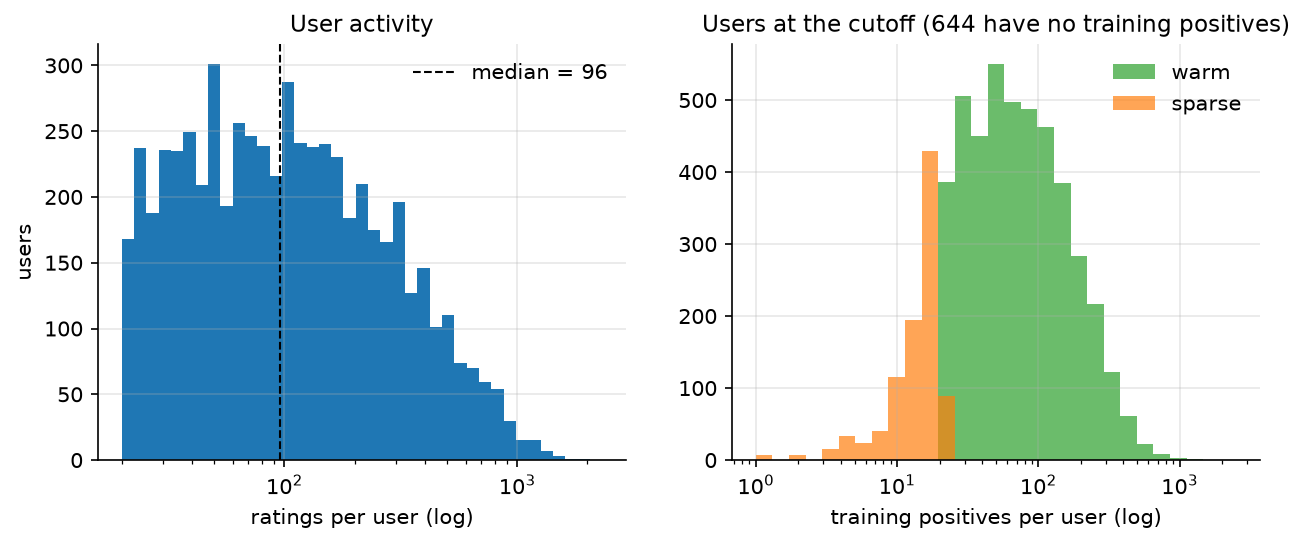

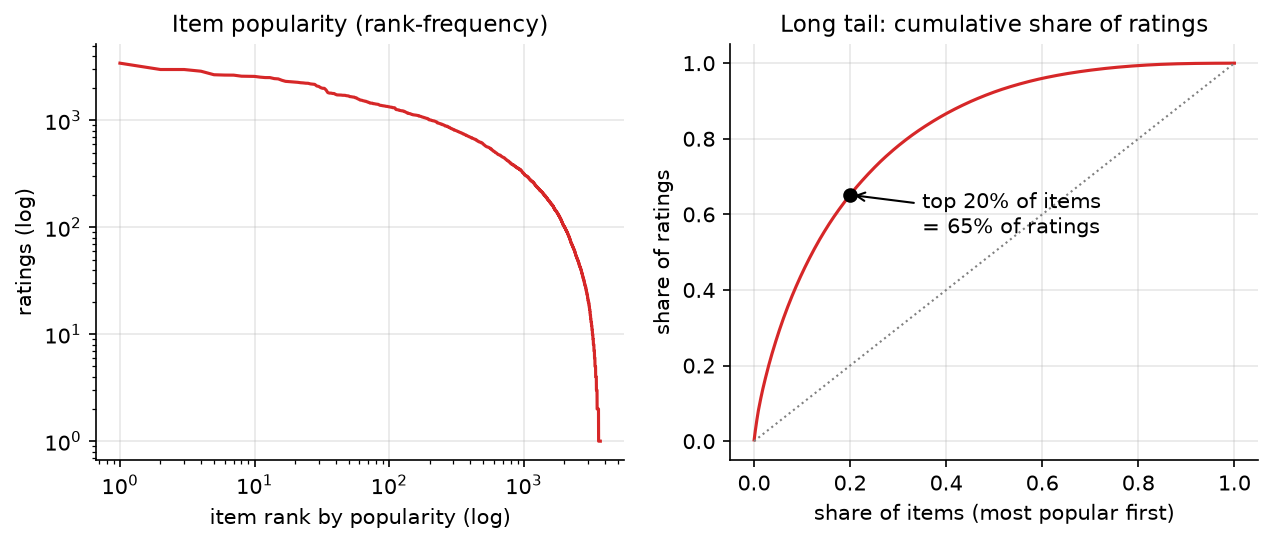

In [6]:
display(Image(eda.plot_user_activity(data)))
display(Image(eda.plot_item_popularity(data)))

Both distributions are heavy-tailed. A few hundred blockbusters collect most ratings: the top 20% of movies get about 65% of all ratings. For the graph models this means some item nodes have thousands of neighbours, while 446 movies have fewer than 10 ratings.

In [7]:
# which movies are those?
top = per_item.sort_values(ascending=False).head(10)
items.set_index("item_idx").loc[top.index, ["title", "genres"]].assign(ratings=top.values)

,title,genres,ratings
item_idx,,,
2651,American Beauty (1999),Comedy|Drama,3428
253,Star Wars: Episode IV - A New Hope (1977),Action|Adventure|Fantasy|Sci-Fi,2991
1106,Star Wars: Episode V - The Empire Strikes Back...,Action|Adventure|Drama|Sci-Fi|War,2990
1120,Star Wars: Episode VI - Return of the Jedi (1983),Action|Adventure|Romance|Sci-Fi|War,2883
466,Jurassic Park (1993),Action|Adventure|Sci-Fi,2672
1848,Saving Private Ryan (1998),Action|Drama|War,2653
575,Terminator 2: Judgment Day (1991),Action|Sci-Fi|Thriller,2649
2374,"Matrix, The (1999)",Action|Sci-Fi|Thriller,2590
1178,Back to the Future (1985),Comedy|Sci-Fi,2583


## Time

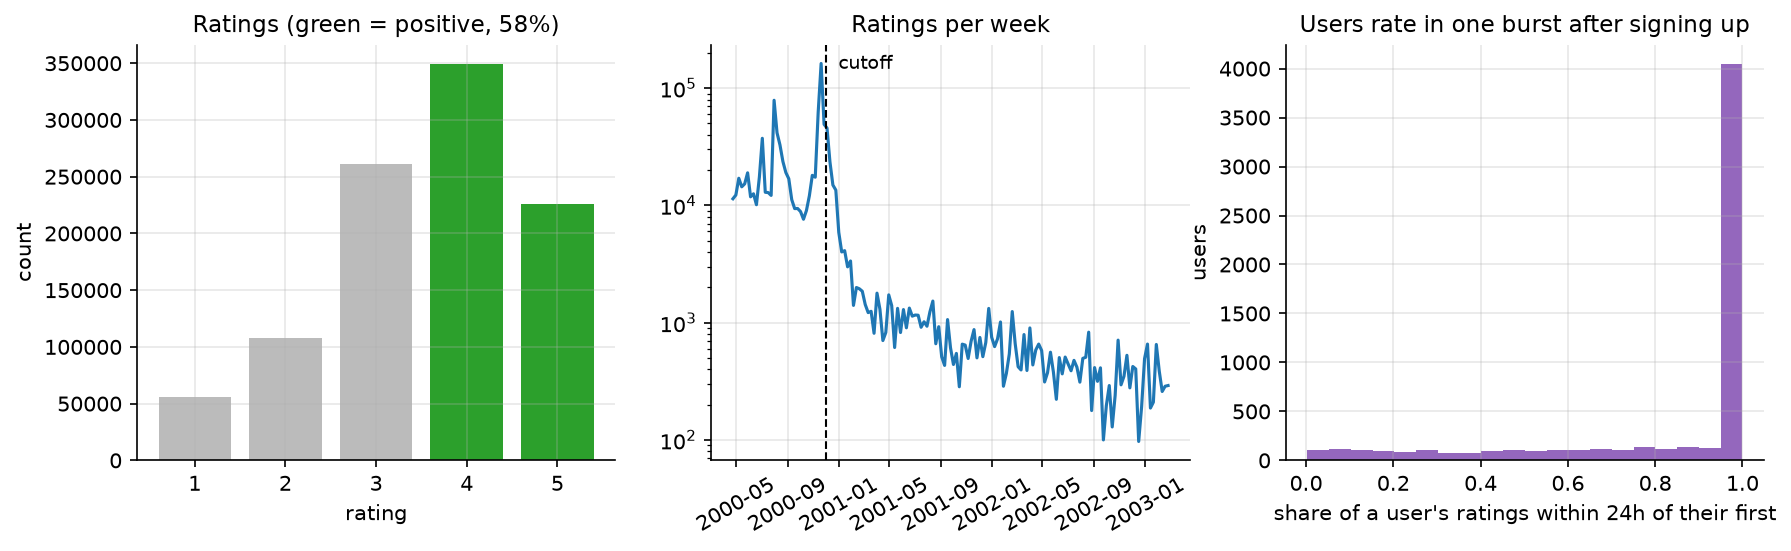

median_share_of_ratings_in_first_24h          1.000000
users_with_half_their_ratings_in_first_24h    0.844040
users_with_all_ratings_in_first_24h           0.629305
median_active_span_days                       0.047089
dtype: float64

In [8]:
display(Image(eda.plot_ratings_and_time(data)))
pd.Series(eda.burst_stats(inter))

This is the most important plot for the evaluation design. Most users rate everything in one session right after signing up (63% of users have all their ratings inside 24 hours, median span about an hour). Activity is huge in 2000 and only a trickle after 2001.

Consequence: a plain chronological train/val/test split gives a validation window full of brand-new users (Dec 2000 sign-ups) and a test window of the few long-term users who came back in 2001-2003. That is why the project uses one cutoff and splits the users after the cutoff into validation and test users (see `data/README.md`).

In [9]:
# how different is "popular before the cutoff" from "popular after the cutoff"?
pos = inter[inter["positive"]]
before = pos[pos["period"] == "train"]["item_idx"].value_counts().head(100).index
after = pos[pos["period"] == "eval"]["item_idx"].value_counts().head(100).index
print("overlap of the top-100 lists:", len(set(before) & set(after)))
newest = items.set_index("item_idx").loc[after[:15], ["title", "year"]]
newest

overlap of the top-100 lists: 82


,title,year
item_idx,,
3341,Gladiator (2000),2000.0
2651,American Beauty (1999),1999.0
253,Star Wars: Episode IV - A New Hope (1977),1977.0
1106,Star Wars: Episode V - The Empire Strikes Back...,1980.0
2557,"Sixth Sense, The (1999)",1999.0
579,"Silence of the Lambs, The (1991)",1991.0
1108,Raiders of the Lost Ark (1981),1981.0
3651,Almost Famous (2000),2000.0
1848,Saving Private Ryan (1998),1998.0


82 of the 100 most liked movies after the cutoff were already in the top 100 before it, so popularity is mostly stable. Half of the 18 newcomers are 2000 releases (Almost Famous, Chicken Run, Meet the Parents, ...), the rest are older films. Because of this recency component a "recent popularity" baseline is included next to the all-time one.

## Metadata

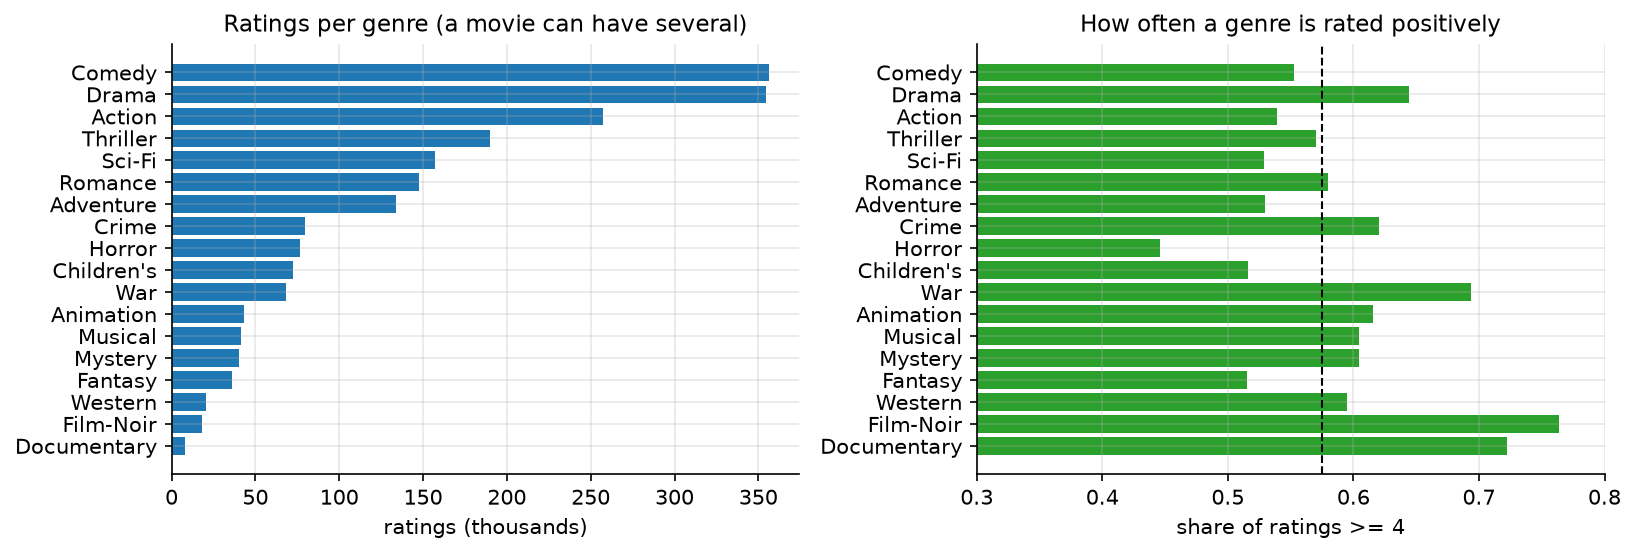

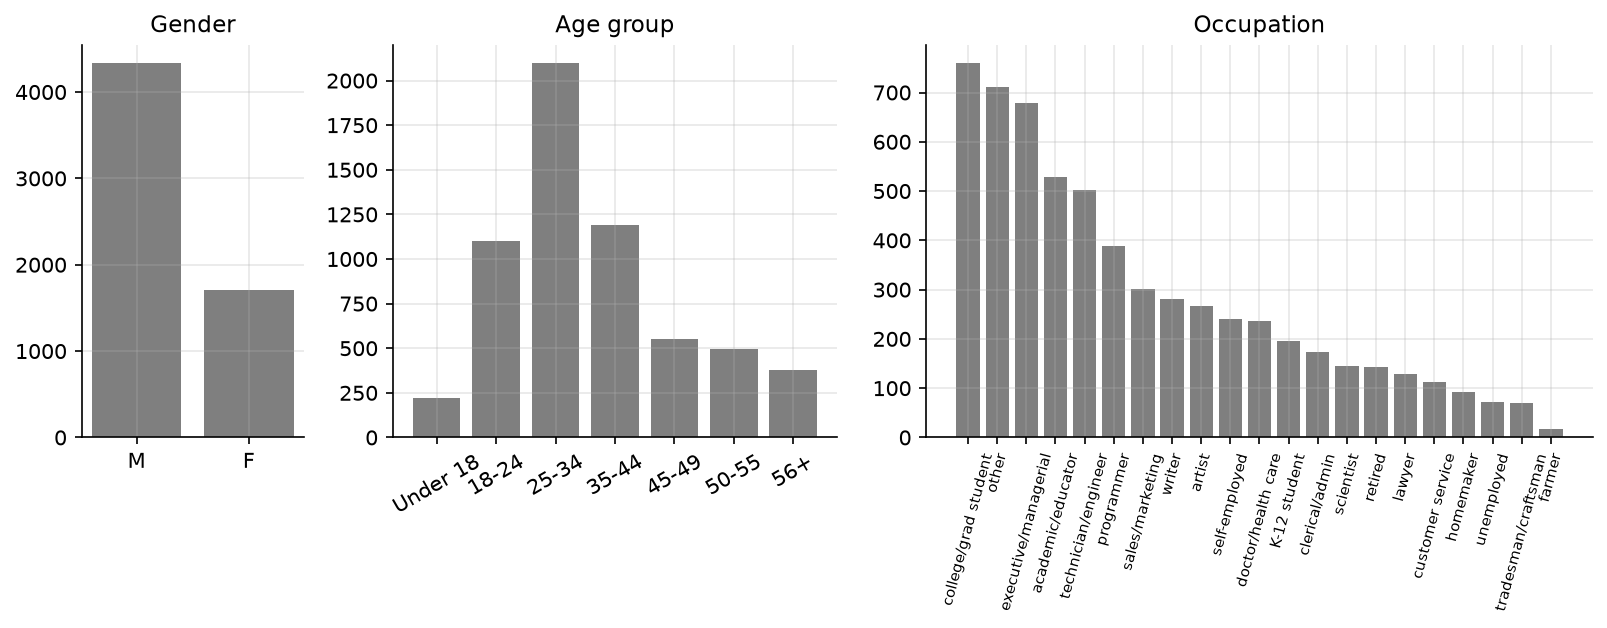

In [10]:
out = eda.plot_genres(data)
display(Image(out[0]))
display(Image(eda.plot_demographics(data)))

In [11]:
# average rating per age group and gender - is there any signal in demographics at all?
m = inter.merge(users[["user_idx", "gender", "age"]], on="user_idx")
m.pivot_table(index="age", columns="gender", values="positive", aggfunc="mean").round(3)

gender,F,M
age,,
1,0.605,0.559
18,0.526,0.557
25,0.586,0.556
35,0.602,0.581
45,0.609,0.585
50,0.655,0.611
56,0.706,0.628


The positive rate rises with age (about 0.53-0.56 for 18-24 year olds, 0.63-0.71 for 56+), so demographics are not useless. Whether they say anything about *which* movies a new user will like is a different question, the cold-user results answer it. For a brand-new user they are all the information there is.

In [12]:
# genre preference by gender: share of positives that go to each genre
g = data.genre_matrix()
share = {}
for sex in ("F", "M"):
    rows = pos[pos["user_idx"].isin(users.loc[users["gender"] == sex, "user_idx"])]["item_idx"].to_numpy()
    share[sex] = g[rows].sum(0) / g[rows].sum()
from recsysx.data.movielens import GENRES
pd.DataFrame(share, index=GENRES).assign(diff=lambda d: d["F"] - d["M"]).sort_values("diff").round(3)

,F,M,diff
Action,0.083,0.126,-0.043
Sci-Fi,0.048,0.076,-0.027
Thriller,0.078,0.094,-0.016
Adventure,0.050,0.062,-0.012
Crime,0.034,0.043,-0.009
War,0.033,0.042,-0.009
Horror,0.022,0.030,-0.008
Western,0.006,0.011,-0.005
Film-Noir,0.010,0.012,-0.002
Documentary,0.005,0.005,-0.000


## After the split

In [13]:
eda.split_summary(data)

,role,group,users,median_train_positives,median_eval_positives,eval_positives
0,val,warm,488,107.5,23.0,22825
1,val,sparse,72,9.0,38.0,4286
2,val,cold,321,0.0,58.0,26886
3,test,warm,487,103.0,26.0,24770
4,test,sparse,73,6.0,28.0,4296
5,test,cold,321,0.0,51.0,29201


In [14]:
print(data.meta["cutoff_date"])
print("training ratings:", data.meta["n_train_interactions"], " training positives:", data.meta["n_train_positive"])
print("item groups (training positives):", data.meta["item_groups"])

2000-12-02 14:52:18
training ratings: 800164  training positives: 463017
item groups (training positives): {'warm': 2607, 'sparse': 862, 'cold': 237}


Each of the validation and test sets has 881 users: 487-488 warm, 72-73 sparse and 321 cold. The cold users have no training history at all but many targets (median 51-58), because they rated their whole sign-up batch after the cutoff. Any metric averaged over all test users is therefore heavily influenced by how a model handles users it knows nothing about, which is why results are always reported per group as well.